In [ ]:
%matplotlib ipympl  
from IPython.display import HTML

import matplotlib.pyplot as plt
from nengoplotlib.connectomes import plot_connectome, get_correlation_matrix, plot_correlation, InteractiveConnectome
import numpy as np

# To run downlod the files forage,py and grid.py from
# https://github.com/tcstewar/nengo_learning_examples
from forage import model
# or creating your own model here

## Structural connectivity


We have created functions for plotting a connectome from a nengo model object. It has various options, including an edge bundling option.

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


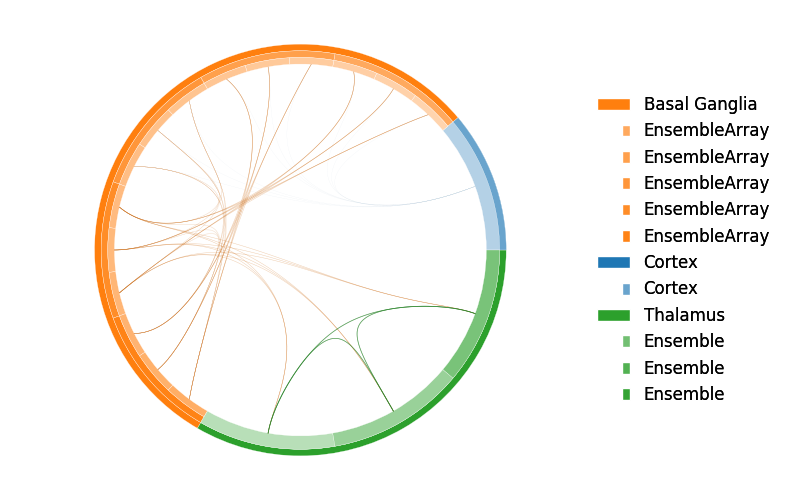

In [2]:

# Examples of different options:
# fig, ax = plt.subplots(figsize=(8,5))
# plot_connectome(model, ax=ax, value_type='n_neurons',arc_params={'lw':0.4})

# plot_connectome(model, value_type='n_neurons', label_type='overlap',font_size=6);

# plot_connectome(model, value_type='n_neurons', max_label_depth=2);

# plot_connectome(model, value_type='equal-n_neurons', equalize_depth=1, max_label_depth=2);

# plot_connectome(model, value_type='equal-n_neurons', equalize_depth=1, 
#                       max_label_depth=2,connection_depth=1);

# plot_connectome(model, value_type='equal-n_neurons', equalize_depth=1, 
#                       max_label_depth=2,connection_depth=3,
#                      connection_type='bundled', arc_params={'lw':0.4}, 
#                       font_size=8, legend_loc='lower right');

plot_connectome(model, size_by='n_neurons', equalize_at=1, 
                      label_depth=1,connection_at=3,
                     connection_type='bundled',
                     total_width=0.1);

# plot_connectome(model, value_type='equal-n_neurons', equalize_depth=1, 
#                       max_label_depth=1,connection_depth=3,
#                      connection_type='bundled',
#                      total_width=0.1, arc_params={'lw':0.4, 'color': 'k', 'alpha':1});
plt.show()



<img src="paper_fig_examples/ssp_slam_connectome.png" alt="Drawing" style="height: 500px;"/>


## Functional connectivity
There are many ways this is computed in practice from neural data. For example, from Shahhosseini & Miranda 2022 (Functional Connectivity Methods and Their Applications in fMRI Data):


> (a) Cross correlation of the average time series in each ROI;
>
> (b) Partial correlation of the average time series in each ROI;
>
> (c) Cross correlation of the time series of the ROI data projected into the space of its first principal component;
>
> (d) Partial correlation of the time series of the ROI data projected into the space of its first principal component;
>
> (e) For each ROI, we consider the principal components that account for 20% of the ROI variability and calculate the RV coefficient as described in Equation 8

Where ROIs means regions of interest, which are generally either voxels or obtained from anatomical atlases. 


In a nengo model, different ensembles (and/or different subnetworks) are the ROIs. We can compute some signal from all ensembles (e.g., activity averaged over the population or averaged neural input or some proxy for BOLD) and then we can do one of the above on the resulting set of time series. Let's do a simple version of this as an example. For more flexibility, use your own code in place of the provided get_correlation_matrix. 

/Users/nicoledumont/Documents/github/nengo_pc/nengo/nengo/cache.py:624: UserWarning: Decoder cache could not acquire lock and was deactivated.
  warnings.warn("Decoder cache could not acquire lock and was deactivated.")


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

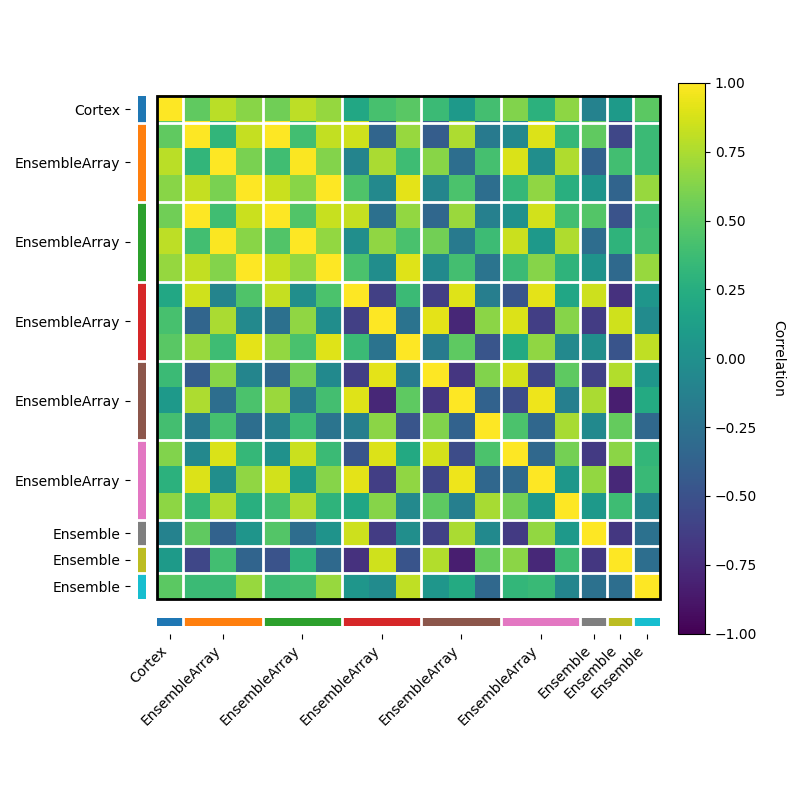

In [3]:

corr, ensembles, signals = get_correlation_matrix(model, T=12)
fig, ax = plot_correlation(corr, model, ensembles=ensembles, label_depth=1)


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


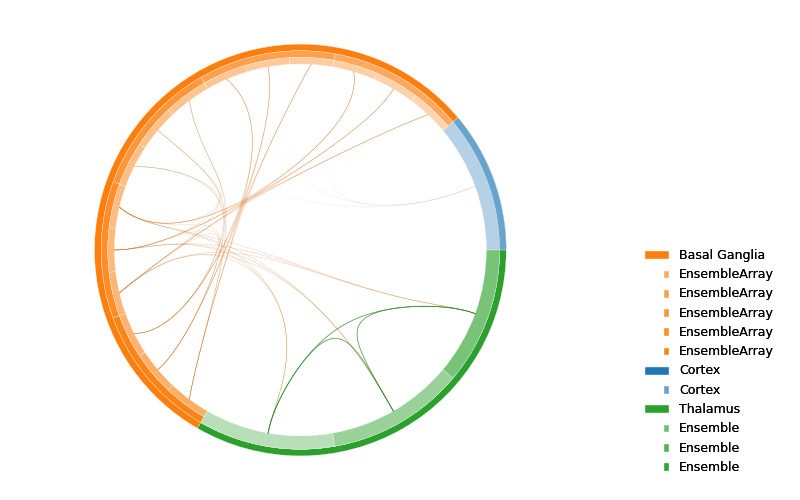

In [4]:
ax, fig, plot_objs= plot_connectome(model, size_by='n_neurons', equalize_at=1, 
                      label_depth=1,connection_at=3,
                     connection_type='bundled',
                     total_width=0.1, 
                     font_size=9,legend_loc='lower right');

handler = InteractiveConnectome(fig, ax, plot_objs['wedges'], plot_objs['lines'],
                               times=np.linspace(0.001,12,len(list(signals.values())[0])),
                                signals=signals)